In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path

import ssqueezepy as sq
from sys import path
path.append('../../')
import wavelet_funcs as wf

In [2]:
wlt = sq.Wavelet('gmw')

In [3]:
wlt.config

{'gamma': 3.0,
 'beta': 60.0,
 'norm': 'bandpass',
 'order': 0.0,
 'centered_scale': False,
 'dtype': 'float32'}

In [4]:
wlt.info()

GMW L1 wavelet
	gamma=3, beta=60
	Center frequency: 2.714000   [wc_ct, (cycles*radians)]
	Time resolution:  9.498688   [std_t, non-dimensional]
	Freq resolution:  0.052639   [std_w, non-dimensional]
	Heisenberg area:  0.500001213619


## Synthetic signal

In [9]:
nt = 2015

dt = 0.5
fs = 1/dt
t = np.arange(nt)*dt

fsignal = 0.03
x = np.cos(2*np.pi*fsignal*t)


### What are different padding options in ssqueezepy?

In [62]:
# Allowed padding types:
help(sq.utils.padsignal)

Help on function padsignal in module ssqueezepy.utils.common:

padsignal(x, padtype='reflect', padlength=None, get_params=False)
    Pads signal and returns trim indices to recover original.
    
    # Arguments:
        x: np.ndarray / torch.Tensor
            Input vector, 1D or 2D. 2D has time in dim1, e.g. `(n_inputs, time)`.
    
        padtype: str
            Pad scheme to apply on input. One of:
                ('reflect', 'symmetric', 'replicate', 'wrap', 'zero').
            'zero' is most naive, while 'reflect' (default) partly mitigates
            boundary effects. See [1] & [2].
    
            Torch doesn't support all padding schemes, but `cwt` will still
            pad it via NumPy.
    
        padlength: int / None
            Number of samples to pad input to (i.e. len(x_padded) == padlength).
            Even: left = right, Odd: left = right + 1.
            Defaults to next highest power of 2 w.r.t. `len(x)`.
    
    # Returns:
        xp: np.ndarray
         

## Reflect

In [65]:
wx, scales = sq.cwt(x, wavelet=wlt, fs=fs, padtype='reflect')
freqs = sq.experimental.scale_to_freq(scales, wavelet=wlt, N=nt, fs=fs)

Text(0.5, 1.0, 'Morse CWT Amplitude (TimeBandwidth=15)')

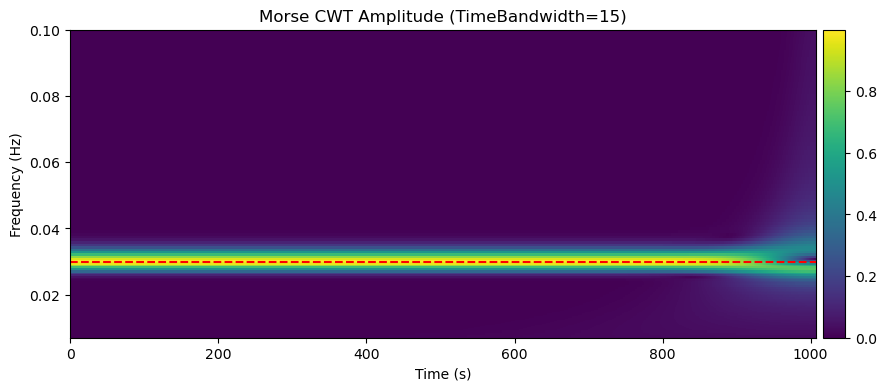

In [67]:
f, ax = wf.plot_cwt(abs(wx), freqs, t, add_colorbar=True)
# ax.plot(t, coi, color='w', ls='--')
# ax.set_ylim([freqs.min(), freqs.max()])
ax.set_ylim([0.007, 0.1])
ax.axhline(fsignal, ls='--', color='r')
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

Done only on the left part of the data?

## wrap

In [70]:
wx, scales = sq.cwt(x, wavelet=wlt, fs=fs, padtype='wrap')
freqs = sq.experimental.scale_to_freq(scales, wavelet=wlt, N=nt, fs=fs)

Text(0.5, 1.0, 'Morse CWT Amplitude (TimeBandwidth=15)')

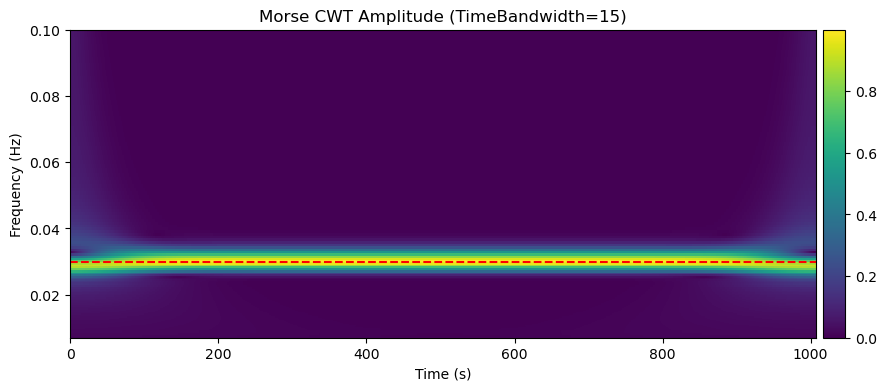

In [72]:
f, ax = wf.plot_cwt(abs(wx), freqs, t, add_colorbar=True)
# ax.plot(t, coi, color='w', ls='--')
# ax.set_ylim([freqs.min(), freqs.max()])
ax.set_ylim([0.007, 0.1])
ax.axhline(fsignal, ls='--', color='r')
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

## Zero

In [76]:
wx, scales = sq.cwt(x, wavelet=wlt, fs=fs, padtype='zero')
freqs = sq.experimental.scale_to_freq(scales, wavelet=wlt, N=nt, fs=fs)

Text(0.5, 1.0, 'Morse CWT Amplitude (TimeBandwidth=15)')

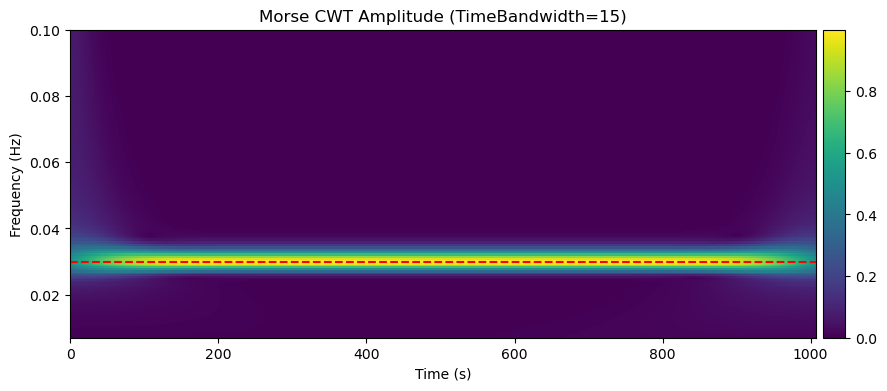

In [78]:
f, ax = wf.plot_cwt(abs(wx), freqs, t, add_colorbar=True)
# ax.plot(t, coi, color='w', ls='--')
# ax.set_ylim([freqs.min(), freqs.max()])
ax.set_ylim([0.007, 0.1])
ax.axhline(fsignal, ls='--', color='r')
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

### Builtin ssqueezepy's imshow missplaces frequency ticks?

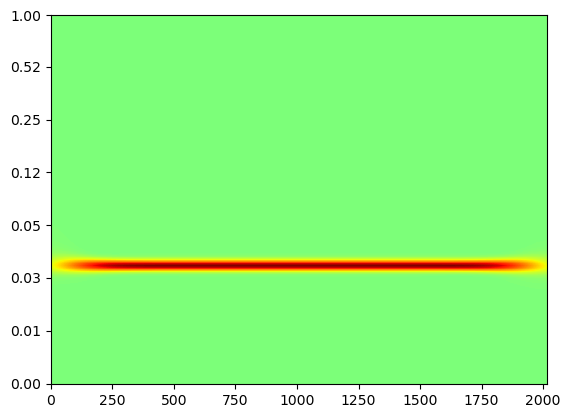

In [81]:
f, ax = plt.subplots()
sq.visuals.imshow(abs(wx)**2, yticks=freqs, cmap='jet', ax=ax)